Train: (3000888, 6) | Test: (28512, 5) | Stores: (54, 5) | Oil: (1218, 2) | Holidays: (350, 6)

===== TRAIN =====
   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0

Missing values:
 id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

===== STORES =====
   store_nbr   city      state type  cluster
0          1  Quito  Pichincha    D       13
1          2  Quito  Pichincha    D       13
2          3  Quito  Pichincha    D        8

Missing values:
 store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

===== OIL =====
         date  dcoilwtico
0  2013-01-01         NaN
1  2013-01-02       93.14
2  2013-01-03       92.97

Missing values:
 date           0
dcoilwtico    43
dtype: int64

===== HOLIDAYS =

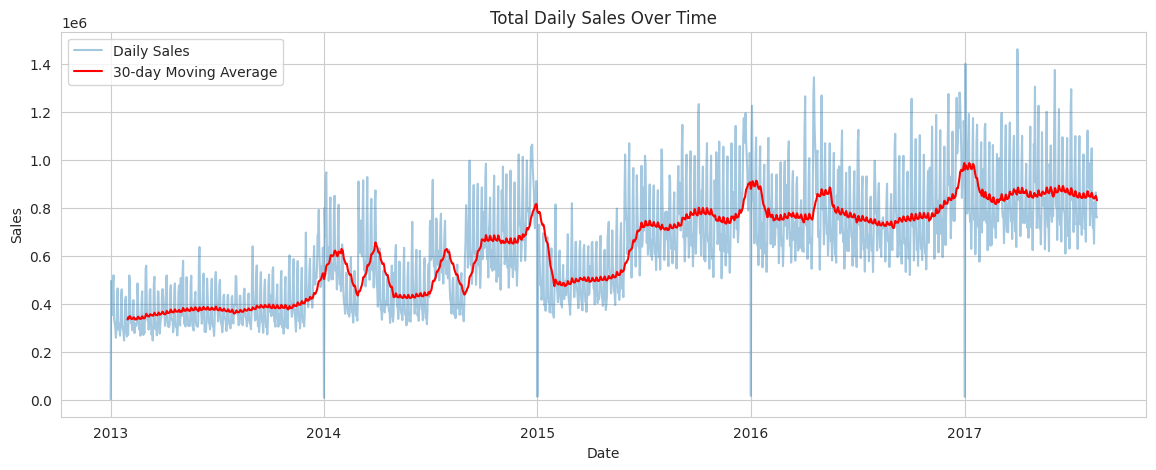

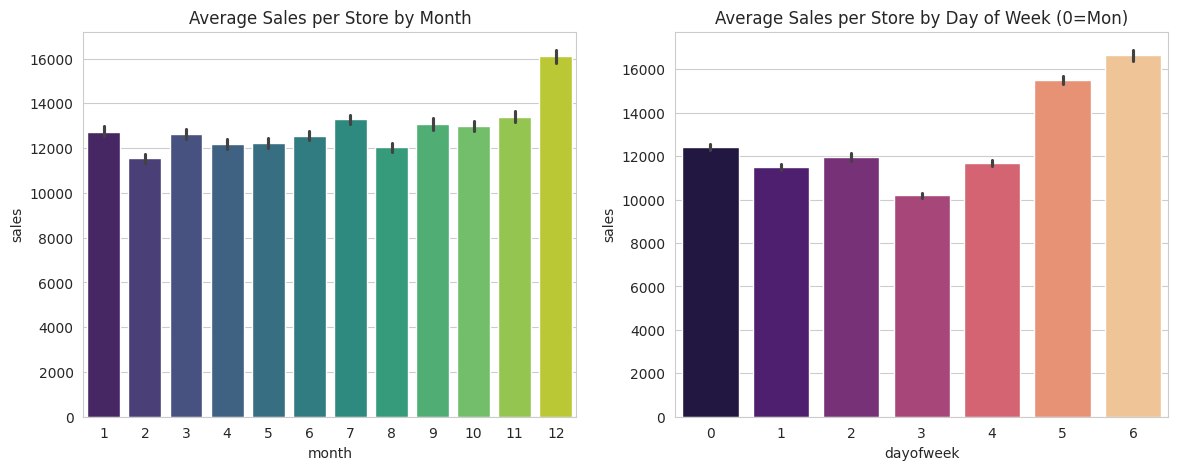

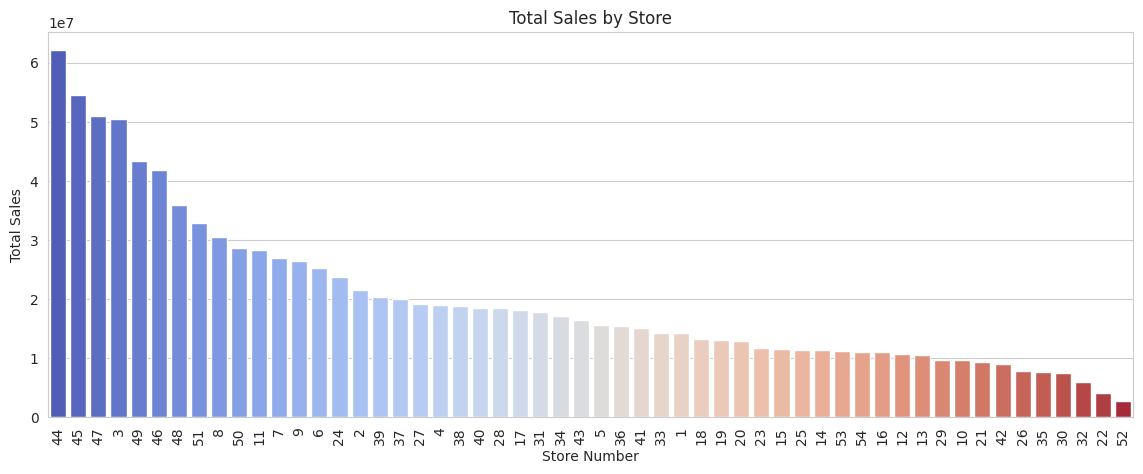

Top 5 stores:
 store_nbr
44    6.208755e+07
45    5.449801e+07
47    5.094831e+07
3     5.048191e+07
49    4.342010e+07
Name: sales, dtype: float64 

Bottom 5 stores:
 store_nbr
35    7.676679e+06
30    7.382074e+06
32    5.951796e+06
22    4.090202e+06
52    2.696170e+06
Name: sales, dtype: float64


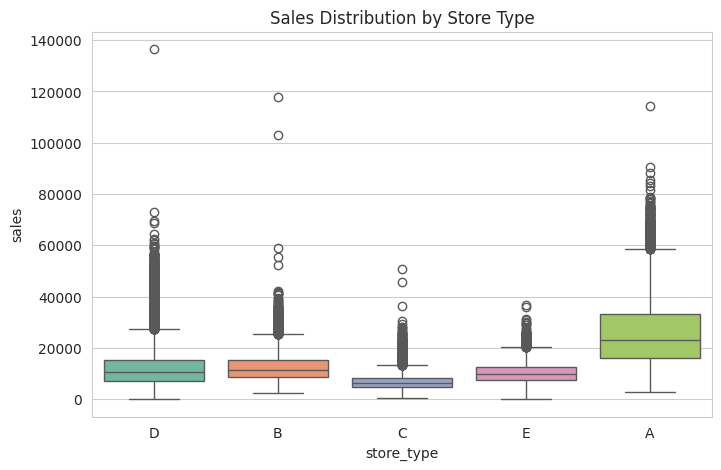

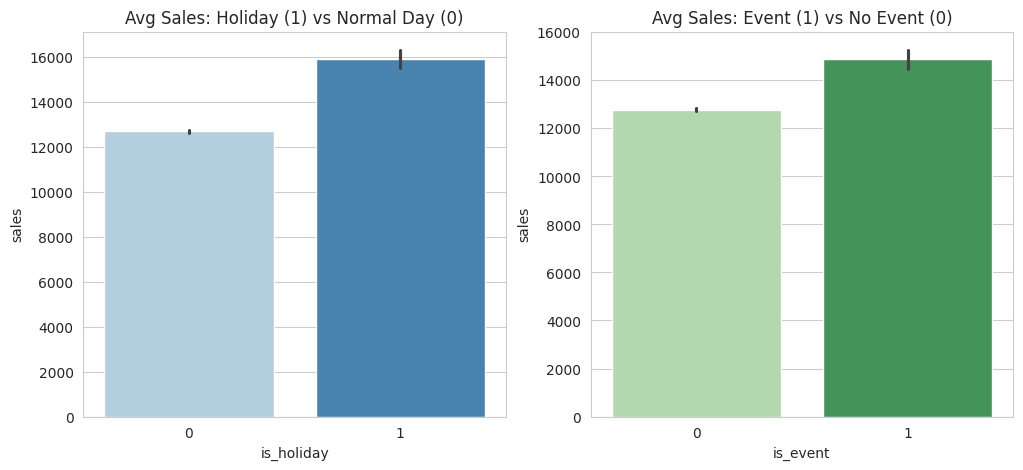

is_holiday
0    12698.661997
1    15927.770333
Name: sales, dtype: float64 

is_event
0    12771.658325
1    14861.450085
Name: sales, dtype: float64


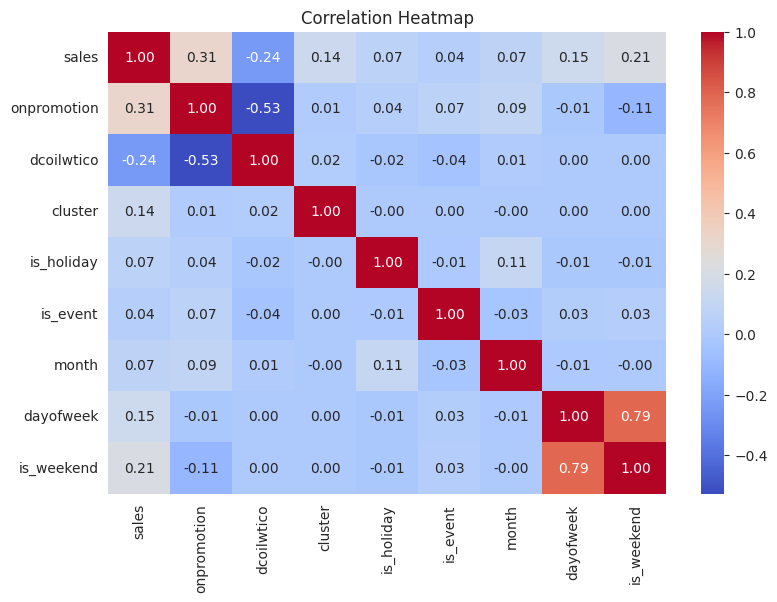

Split date: 2017-05-17
Training set: (78746, 15) | Testing set: (4860, 15)
Model trained successfully!
MAE  : 1,572.58
MSE  : 5,833,445.65
RMSE : 2,415.25
R2   : 0.9474


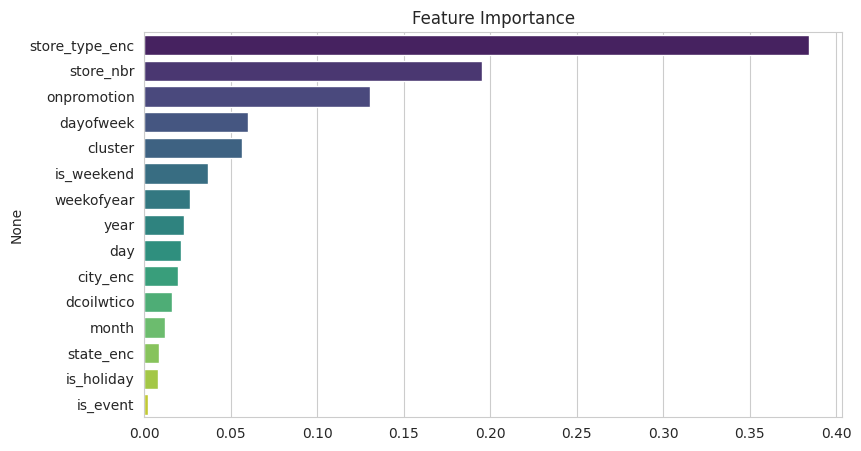

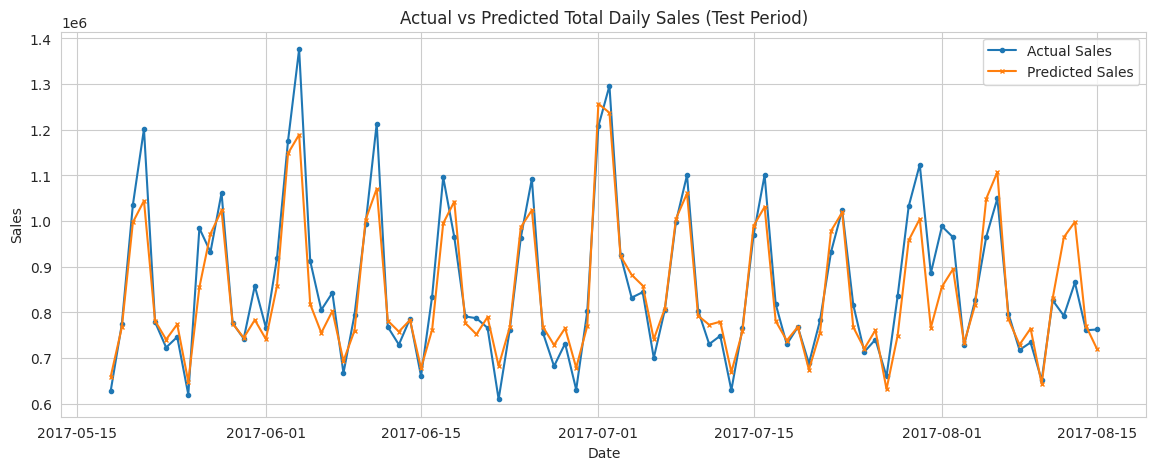

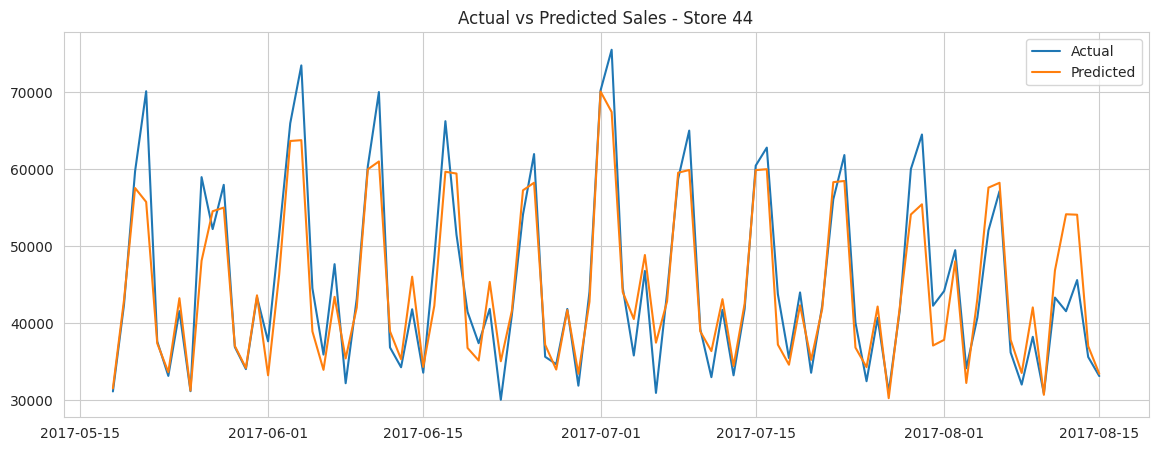

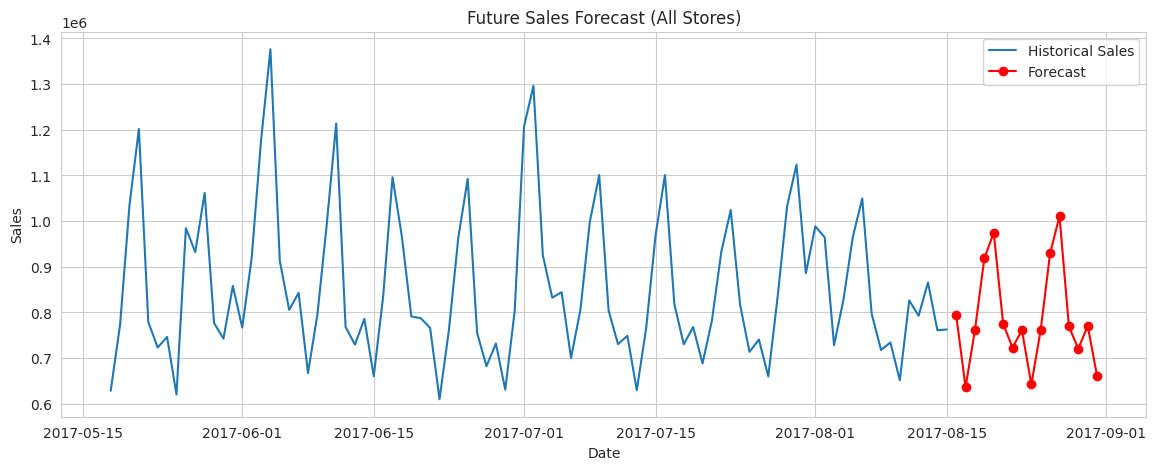

===== FUTURE TOTAL SALES FORECAST (ALL STORES) =====


,date,day_name,predicted_sales
0,2017-08-16,Wednesday,794378.82
1,2017-08-17,Thursday,636082.78
2,2017-08-18,Friday,761884.11
3,2017-08-19,Saturday,918495.09
4,2017-08-20,Sunday,974469.61
5,2017-08-21,Monday,775105.71
6,2017-08-22,Tuesday,722918.46
7,2017-08-23,Wednesday,761156.96
8,2017-08-24,Thursday,642161.61
9,2017-08-25,Friday,762174.84


===== FUTURE SALES FORECAST BY STORE (sample) =====


,date,store_nbr,city,store_type,predicted_sales
0,2017-08-16,1,Quito,D,14841.02
1,2017-08-16,2,Quito,D,15124.48
2,2017-08-16,3,Quito,D,37536.90
3,2017-08-16,4,Quito,D,14220.07
4,2017-08-16,5,Santo Domingo,D,9922.76
5,2017-08-16,6,Quito,D,16600.11
6,2017-08-16,7,Quito,D,23830.71
7,2017-08-16,8,Quito,D,23732.17
8,2017-08-16,9,Quito,B,14849.63
9,2017-08-16,10,Quito,C,5984.24


===== MODEL PERFORMANCE SUMMARY =====


,Metric,Value
0,MAE,1.572580e+03
1,MSE,5.833446e+06
2,RMSE,2.415250e+03
3,R2 Score,9.474000e-01


In [ ]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import os, glob, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# Output: no output (libraries imported)


# ============================================================
# 2. LOAD DATASET (auto-detects files in Colab)
# ============================================================
DATA_DIR = "/content/store_sales_data"
os.makedirs(DATA_DIR, exist_ok=True)

def find_file(name, root="/content"):
    for folder, _, fnames in os.walk(root):
        if name in fnames:
            return os.path.join(folder, name)
    return None

# If train.csv is not found yet, look for a zip file and extract it
if find_file("train.csv") is None:
    zips = glob.glob("/content/**/*.zip", recursive=True)
    if not zips:
        from google.colab import files
        print("No dataset found. Please upload the zip file...")
        uploaded = files.upload()
        zips = ["/content/" + f for f in uploaded.keys() if f.endswith(".zip")]
    for z in zips:
        with zipfile.ZipFile(z, "r") as zf:
            zf.extractall(DATA_DIR)

train     = pd.read_csv(find_file("train.csv"))
test      = pd.read_csv(find_file("test.csv"))
stores    = pd.read_csv(find_file("stores.csv"))
oil       = pd.read_csv(find_file("oil.csv"))
holidays  = pd.read_csv(find_file("holidays_events.csv"))
transactions = pd.read_csv(find_file("transactions.csv"))

print("Train:", train.shape, "| Test:", test.shape, "| Stores:", stores.shape,
      "| Oil:", oil.shape, "| Holidays:", holidays.shape)
train.head()

# Output: shapes of all datasets (train ~3 million rows) + first 5 rows of train (DataFrame)


# ============================================================
# 3. DATA UNDERSTANDING
# ============================================================
for name, d in [("TRAIN", train), ("STORES", stores), ("OIL", oil), ("HOLIDAYS", holidays)]:
    print(f"\n===== {name} =====")
    print(d.head(3))
    print("\nMissing values:\n", d.isnull().sum())

print("\nTrain sales summary:")
print(train["sales"].describe())

# Output: first rows, missing value counts per column and summary statistics (DataFrames/Series)


# ============================================================
# 4. DATA CLEANING
# ============================================================
# --- Convert date columns to datetime ---
for d in [train, test, oil, holidays, transactions]:
    d["date"] = pd.to_datetime(d["date"])

# --- Remove duplicates ---
print("Duplicates before:", train.duplicated().sum(), holidays.duplicated().sum(), stores.duplicated().sum())
train = train.drop_duplicates()
holidays = holidays.drop_duplicates()
stores = stores.drop_duplicates()

# --- Handle missing values in oil prices (fill gaps using neighbouring days) ---
all_dates = pd.date_range(train["date"].min(), test["date"].max())
oil = oil.set_index("date").reindex(all_dates)
oil["dcoilwtico"] = oil["dcoilwtico"].interpolate().ffill().bfill()
oil = oil.rename_axis("date").reset_index()
print("Missing oil values after cleaning:", oil["dcoilwtico"].isnull().sum())

# --- Holidays: ignore transferred holidays (they were not celebrated on that day) ---
holidays = holidays[holidays["transferred"] == False]
national_holidays = holidays[(holidays["locale"] == "National") &
                             (holidays["type"].isin(["Holiday", "Transfer", "Additional", "Bridge"]))]["date"].unique()
event_dates = holidays[holidays["type"] == "Event"]["date"].unique()

# --- Aggregate to Store-Day level (total sales & promotions per store per day) ---
daily = train.groupby(["date", "store_nbr"]).agg(sales=("sales", "sum"),
                                                 onpromotion=("onpromotion", "sum")).reset_index()
# Remove days when a store had zero sales (store not yet opened / closed)
daily = daily[daily["sales"] > 0].reset_index(drop=True)

# Same aggregation for test data (future period)
future = test.groupby(["date", "store_nbr"]).agg(onpromotion=("onpromotion", "sum")).reset_index()

print("Daily train shape:", daily.shape, "| Future shape:", future.shape)
print("Date range:", daily["date"].min().date(), "to", daily["date"].max().date())
print("Future range:", future["date"].min().date(), "to", future["date"].max().date())

# Output: duplicate counts, missing oil values = 0, shapes (~90k rows) and date ranges


# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================
stores = stores.rename(columns={"type": "store_type"})

def build_features(df):
    df = df.merge(stores, on="store_nbr", how="left")                 # store information
    df = df.merge(oil[["date", "dcoilwtico"]], on="date", how="left") # oil price
    df["is_holiday"] = df["date"].isin(national_holidays).astype(int) # holiday flag
    df["is_event"]   = df["date"].isin(event_dates).astype(int)       # event flag
    # Time-based features
    df["year"]       = df["date"].dt.year
    df["month"]      = df["date"].dt.month
    df["day"]        = df["date"].dt.day
    df["dayofweek"]  = df["date"].dt.dayofweek
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    return df

data   = build_features(daily)
future = build_features(future)

# Encode categorical variables (fit on all store info so train/future use same codes)
for col in ["store_type", "city", "state"]:
    le = LabelEncoder().fit(stores[col])
    data[col + "_enc"]   = le.transform(data[col])
    future[col + "_enc"] = le.transform(future[col])

data.head()

# Output: DataFrame with new columns (year, month, day, dayofweek, weekofyear, is_holiday, is_event, encoded columns)


# ============================================================
# 6. EXPLORATORY DATA ANALYSIS
# ============================================================
# --- 6.1 Total sales trend over time ---
total_daily = data.groupby("date")["sales"].sum()
plt.figure(figsize=(14, 5))
plt.plot(total_daily.index, total_daily.values, alpha=0.4, label="Daily Sales")
plt.plot(total_daily.index, total_daily.rolling(30).mean(), color="red", label="30-day Moving Average")
plt.title("Total Daily Sales Over Time"); plt.xlabel("Date"); plt.ylabel("Sales"); plt.legend()
plt.show()
# Output: line graph showing upward sales trend with yearly seasonality

# --- 6.2 Monthly and yearly patterns ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x="month", y="sales", data=data, ax=ax[0], palette="viridis")
ax[0].set_title("Average Sales per Store by Month")
sns.barplot(x="dayofweek", y="sales", data=data, ax=ax[1], palette="magma")
ax[1].set_title("Average Sales per Store by Day of Week (0=Mon)")
plt.show()
# Output: two bar charts (December peak, weekend peak)

# --- 6.3 Sales by store ---
store_sales = data.groupby("store_nbr")["sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(14, 5))
sns.barplot(x=store_sales.index.astype(str), y=store_sales.values, palette="coolwarm")
plt.title("Total Sales by Store"); plt.xlabel("Store Number"); plt.ylabel("Total Sales")
plt.xticks(rotation=90); plt.show()
# Output: bar chart of total sales for all stores (sorted)

print("Top 5 stores:\n", store_sales.head(), "\n\nBottom 5 stores:\n", store_sales.tail())
# Output: Series with top 5 and bottom 5 stores

# --- 6.4 Sales by store type ---
plt.figure(figsize=(8, 5))
sns.boxplot(x="store_type", y="sales", data=data, palette="Set2")
plt.title("Sales Distribution by Store Type"); plt.show()
# Output: boxplot comparing store types A-E

# --- 6.5 Effect of holidays and events ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x="is_holiday", y="sales", data=data, ax=ax[0], palette="Blues")
ax[0].set_title("Avg Sales: Holiday (1) vs Normal Day (0)")
sns.barplot(x="is_event", y="sales", data=data, ax=ax[1], palette="Greens")
ax[1].set_title("Avg Sales: Event (1) vs No Event (0)")
plt.show()
# Output: two bar charts comparing average sales on holidays/events vs normal days

print(data.groupby("is_holiday")["sales"].mean(), "\n")
print(data.groupby("is_event")["sales"].mean())
# Output: average sales values for holiday/non-holiday and event/non-event days

# --- 6.6 Correlation heatmap ---
corr_cols = ["sales", "onpromotion", "dcoilwtico", "cluster", "is_holiday", "is_event",
             "month", "dayofweek", "is_weekend"]
plt.figure(figsize=(9, 6))
sns.heatmap(data[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap"); plt.show()
# Output: correlation heatmap


# ============================================================
# 7. MODEL BUILDING
# ============================================================
features = ["store_nbr", "cluster", "store_type_enc", "city_enc", "state_enc",
            "onpromotion", "dcoilwtico", "is_holiday", "is_event",
            "year", "month", "day", "dayofweek", "weekofyear", "is_weekend"]
target = "sales"

# Chronological split: last 90 days = test set (NO random shuffling)
split_date = data["date"].max() - pd.Timedelta(days=90)
train_df = data[data["date"] <= split_date]
test_df  = data[data["date"] >  split_date]

X_train, y_train = train_df[features], train_df[target]
X_test,  y_test  = test_df[features],  test_df[target]

print("Split date:", split_date.date())
print("Training set:", X_train.shape, "| Testing set:", X_test.shape)

model = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=2,
                              n_jobs=-1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Model trained successfully!")

# Output: split date, training/testing shapes, "Model trained successfully!"


# ============================================================
# 8. MODEL EVALUATION
# ============================================================
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R2   : {r2:.4f}")

# Feature importance
imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(x=imp.values, y=imp.index, palette="viridis")
plt.title("Feature Importance"); plt.show()

# Output: MAE, MSE, RMSE, R2 values (R2 usually ~0.9+) and a feature importance bar chart


# ============================================================
# 9. ACTUAL vs PREDICTED SALES
# ============================================================
compare = test_df[["date", "store_nbr", "sales"]].copy()
compare["predicted"] = y_pred

# Total sales across all stores per day
daily_cmp = compare.groupby("date")[["sales", "predicted"]].sum()
plt.figure(figsize=(14, 5))
plt.plot(daily_cmp.index, daily_cmp["sales"], label="Actual Sales", marker="o", markersize=3)
plt.plot(daily_cmp.index, daily_cmp["predicted"], label="Predicted Sales", marker="x", markersize=3)
plt.title("Actual vs Predicted Total Daily Sales (Test Period)")
plt.xlabel("Date"); plt.ylabel("Sales"); plt.legend(); plt.show()
# Output: line graph with actual and predicted lines closely following each other

# Example: single store comparison (store 44)
one = compare[compare["store_nbr"] == 44]
plt.figure(figsize=(14, 5))
plt.plot(one["date"], one["sales"], label="Actual")
plt.plot(one["date"], one["predicted"], label="Predicted")
plt.title("Actual vs Predicted Sales - Store 44"); plt.legend(); plt.show()
# Output: line graph for store 44


# ============================================================
# 10. FUTURE SALES FORECAST
# ============================================================
# Retrain on ALL available data, then predict the future period (test.csv dates)
final_model = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=2,
                                    n_jobs=-1, random_state=42)
final_model.fit(data[features], data[target])

future["predicted_sales"] = final_model.predict(future[features])

future_total = future.groupby("date")["predicted_sales"].sum().reset_index()
future_total["predicted_sales"] = future_total["predicted_sales"].round(2)

# Plot: recent history + forecast
history = total_daily[-90:]
plt.figure(figsize=(14, 5))
plt.plot(history.index, history.values, label="Historical Sales")
plt.plot(future_total["date"], future_total["predicted_sales"], color="red", marker="o", label="Forecast")
plt.title("Future Sales Forecast (All Stores)"); plt.xlabel("Date"); plt.ylabel("Sales"); plt.legend()
plt.show()
# Output: line graph with last 90 days of history and the forecast in red


# ============================================================
# 11. FINAL RESULTS
# ============================================================
print("===== FUTURE TOTAL SALES FORECAST (ALL STORES) =====")
future_total["day_name"] = future_total["date"].dt.day_name()
display(future_total[["date", "day_name", "predicted_sales"]])
# Output: table of ~16 future dates with predicted total sales

print("===== FUTURE SALES FORECAST BY STORE (sample) =====")
display(future[["date", "store_nbr", "city", "store_type", "predicted_sales"]]
        .round(2).sort_values(["date", "store_nbr"]).head(20))
# Output: table of store-wise predicted sales for future dates

print("===== MODEL PERFORMANCE SUMMARY =====")
display(pd.DataFrame({"Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
                      "Value": [round(mae, 2), round(mse, 2), round(rmse, 2), round(r2, 4)]}))
# Output: summary table of evaluation metrics

# Optional: download forecast as CSV
future[["date", "store_nbr", "predicted_sales"]].to_csv("future_sales_forecast.csv", index=False)